# Find stations and historical files

Learn how to search the station catalog, map a region, and identify available archive files before downloading observations.

The first code cell records when this notebook was executed against NOAA services.


In [1]:
from datetime import datetime, timezone
print("NOAA execution started (UTC):", datetime.now(timezone.utc).isoformat())

import matplotlib.pyplot as plt
import xndbc

bounds = {"north": 46, "south": 20, "west": -125, "east": -115}
years = range(1998, 2000)

## Select known station IDs

A station selection is an xarray dataset of locations and metadata. Pass it directly to historical() or realtime() when you are ready to download observations.

Each row has a `station_id` plus its name, owner, type, location, and notes. Calling `xndbc.stations()` without filters returns the full catalog. Known IDs absent from the current catalog are omitted; pass an archive-only station ID directly to `historical()` instead. If both IDs and bounds are supplied to discovery, both filters apply.

In [2]:
xndbc.stations(["44013", "41043"])

<xarray.Dataset> Size: 9kB
Dimensions:       (station_id: 2)
Coordinates:
  * station_id    (station_id) <U7 56B '44013' '41043'
    latitude      (station_id) float64 16B 42.35 21.09
    longitude     (station_id) float64 16B -70.65 -64.86
Data variables:
    name          (station_id) <U76 608B 'BOSTON 16 NM East of Boston, MA' 'N...
    owner         (station_id) <U3 24B 'N' 'N'
    station_type  (station_id) <U40 320B '2.1-meter ionomer foam buoy' '3-met...
    notes         (station_id) <U990 8kB 'Caution: Right whales may be active...
Attributes:
    source:   https://www.ndbc.noaa.gov/data/stations/station_table.txt

## Find and map a region

Bounds use four named coordinates in degrees. Here they describe a region near California. A west bound greater than the east bound selects across the dateline.

These are catalog positions, which may differ from historical deployment positions.

Bounds require exactly `north`, `south`, `west`, and `east` in finite degrees. Latitudes range from -90 to 90 and longitudes from -180 to 180; south cannot exceed north. Unknown locations cannot match bounds. Catalogs and archive indexes are cached in memory; pass `refresh=True` to discovery to refresh metadata after upstream changes.

In [3]:
region = xndbc.stations(bounds=bounds)
region

<xarray.Dataset> Size: 860kB
Dimensions:       (station_id: 192)
Coordinates:
  * station_id    (station_id) <U7 5kB '1801583' '1801589' ... 'tlbo3' 'upbc1'
    latitude      (station_id) float64 2kB 37.36 37.36 37.36 ... 45.55 38.04
    longitude     (station_id) float64 2kB -122.9 -122.9 ... -123.9 -122.1
Data variables:
    name          (station_id) <U76 58kB 'SD 1063 - 24 NM SSW of San Francisc...
    owner         (station_id) <U3 2kB 'N' 'N' 'N' 'N' ... 'NR' 'NR' 'O' 'PT'
    station_type  (station_id) <U40 31kB 'Uncrewed Surface Vehicle' ... 'Wate...
    notes         (station_id) <U990 760kB 'SD-1063 was replaced on 1200Z, 7/...
Attributes:
    source:   https://www.ndbc.noaa.gov/data/stations/station_table.txt

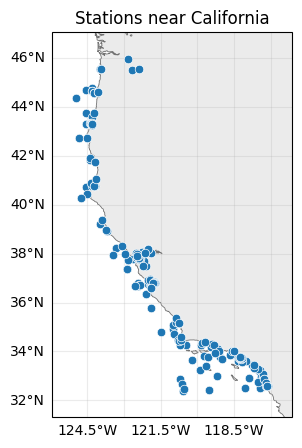

In [4]:
fig, ax = region.ndbc.plot_map(labels=False)
ax.set_title("Stations near California")
plt.show()

## Inspect archive availability

Availability has `station_id` and `year` dimensions. `available` indicates file presence, and `url` identifies the file. A file can exist without containing the measurement you want.

In [5]:
available = region.ndbc.availability(years=years)
available

<xarray.Dataset> Size: 962kB
Dimensions:       (station_id: 192, year: 2)
Coordinates:
  * station_id    (station_id) <U7 5kB '1801583' '1801589' ... 'tlbo3' 'upbc1'
    latitude      (station_id) float64 2kB 37.36 37.36 37.36 ... 45.55 38.04
    longitude     (station_id) float64 2kB -122.9 -122.9 ... -123.9 -122.1
    name          (station_id) <U76 58kB 'SD 1063 - 24 NM SSW of San Francisc...
    owner         (station_id) <U3 2kB 'N' 'N' 'N' 'N' ... 'NR' 'NR' 'O' 'PT'
    station_type  (station_id) <U40 31kB 'Uncrewed Surface Vehicle' ... 'Wate...
    notes         (station_id) <U990 760kB 'SD-1063 was replaced on 1200Z, 7/...
  * year          (year) int64 16B 1998 1999
    mode          <U6 24B 'stdmet'
Data variables:
    available     (station_id, year) bool 384B False False False ... False False
    url           (station_id, year) <U66 101kB '' '' '' '' '' ... '' '' '' ''
Attributes:
    source:       https://www.ndbc.noaa.gov/data/historical/stdmet/
    description:  Archive file presence, not measurement completeness

## Select stations with at least one file

Reduce the availability array over `year`, then use that boolean array to select station IDs. This is a normal xarray selection; the IDs can be passed directly to `historical()`.

In [6]:
has_files = available.available.any("year")
station_ids = available.station_id.isel(station_id=has_files)
station_ids

<xarray.DataArray 'station_id' (station_id: 23)> Size: 644B
array(['46011', '46012', '46013', '46014', '46022', '46023', '46025', '46026',
       '46027', '46028', '46030', '46042', '46045', '46047', '46050', '46053',
       '46054', '46062', '46063', 'caro3', 'nwpo3', 'ptac1', 'ptgc1'],
      dtype='<U7')
Coordinates:
  * station_id    (station_id) <U7 644B '46011' '46012' ... 'ptac1' 'ptgc1'
    latitude      (station_id) float64 184B 34.94 37.36 38.23 ... 38.95 34.58
    longitude     (station_id) float64 184B -121.0 -122.9 ... -123.7 -120.6
    name          (station_id) <U76 7kB 'SANTA MARIA - 21NM NW of Point Argue...
    owner         (station_id) <U3 276B 'N' 'N' 'N' 'N' 'N' ... 'N' 'N' 'N' 'N'
    station_type  (station_id) <U40 4kB '3-meter discus buoy w/ seal cage' .....
    notes         (station_id) <U990 91kB '' ... ''
    mode          <U6 24B 'stdmet'

Choosing stations this way allows missing individual years. Downloads report those missing files through `data.ndbc.report()`. If you change the region or years, inspect the selection before downloading; it may be empty.

Continue with [Historical Analysis](historical_analysis.ipynb) for a small, explicit station selection and an introduction to coverage.

## Pass an xarray selection to retrieval

Downloads accept station datasets, ID strings, ID iterables, and scalar or one-dimensional ID DataArrays. Dataset selections supply their `station_id` coordinate, including after a scalar `sel`. Empty selections raise an error, so inspect regional results before retrieving.

Here a scalar selection retrieves one known station and archive year:

In [ ]:
known = xndbc.stations(["44013", "41043"])
one_station = known.sel(station_id="44013")
observations = xndbc.historical(one_station, years=2020, progress=False)
observations.ndbc.report()

You can also make a direct regional request with `xndbc.historical(bounds=bounds, years=2020)` or `xndbc.realtime(bounds=bounds)`. These resolve the same IDs as explicit discovery. Retrieval takes either a station selection or bounds, not both. Observation files are fetched on each retrieval; `progress=False` hides progress bars but does not suppress warnings.